In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the preprocessed CSV
df = pd.read_csv('flood_data_preprocessed.csv')

In [6]:
# Check the first few rows
df.head()

,Sl,Station_Names,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,...,X_COR,Y_COR,LATITUDE,LONGITUDE,ALT,Period,Flood?,Rainfall log,Wind_Speed log,ALT log
0,0,Barisal,1949,1,29.4,12.3,0.0,68.0,0.453704,0.6,...,536809.8,510151.9,22.7,90.36,4,1949.01,0.0,0.000000,0.374115,1.609438
1,1,Barisal,1949,2,33.9,15.2,9.0,63.0,0.659259,0.9,...,536809.8,510151.9,22.7,90.36,4,1949.02,0.0,2.302585,0.506371,1.609438
2,3,Barisal,1949,4,33.9,23.9,140.0,71.0,1.772222,3.9,...,536809.8,510151.9,22.7,90.36,4,1949.04,0.0,4.948760,1.019649,1.609438
3,4,Barisal,1949,5,35.6,25.0,217.0,76.0,1.703704,4.1,...,536809.8,510151.9,22.7,90.36,4,1949.05,0.0,5.384495,0.994623,1.609438
4,5,Barisal,1949,6,34.4,25.7,512.0,80.0,1.631481,5.6,...,536809.8,510151.9,22.7,90.36,4,1949.06,1.0,6.240276,0.967547,1.609438


In [7]:
print(df['Station_Names'].nunique())


32


In [8]:
station_list = df['Station_Names'].unique().tolist()
print(station_list)


['Barisal', 'Bhola', 'Bogra', 'Chandpur', 'Chittagong (City-Ambagan)', 'Chittagong (IAP-Patenga)', 'Comilla', "Cox's Bazar", 'Dhaka', 'Dinajpur', 'Faridpur', 'Feni', 'Hatiya', 'Ishurdi', 'Jessore', 'Khepupara', 'Khulna', 'Kutubdia', 'Madaripur', 'Maijdee Court', 'Mongla', 'Mymensingh', 'Patuakhali', 'Rajshahi', 'Rangpur', 'Sandwip', 'Satkhira', 'Sitakunda', 'Srimangal', 'Sylhet', 'Tangail', 'Teknaf']


In [10]:
numeric_features = ['Max_Temp','Min_Temp','Rainfall log','Relative_Humidity','Wind_Speed log',
                    'Cloud_Coverage','Bright_Sunshine','X_COR','Y_COR','LATITUDE','LONGITUDE','ALT log','Period']


# One-Hot Encode categorical column
df_dummies = pd.get_dummies(df[['Station_Names']], drop_first=True)

# Combine numeric features and encoded categorical features
X = pd.concat([df[numeric_features], df_dummies], axis=1)

# Define target
y = df['Flood?']

In [11]:
X.shape

(17560, 44)

In [12]:
print(X.dtypes)

Max_Temp                                   float64
Min_Temp                                   float64
Rainfall log                               float64
Relative_Humidity                          float64
Wind_Speed log                             float64
Cloud_Coverage                             float64
Bright_Sunshine                            float64
X_COR                                      float64
Y_COR                                      float64
LATITUDE                                   float64
LONGITUDE                                  float64
ALT log                                    float64
Period                                     float64
Station_Names_Bhola                           bool
Station_Names_Bogra                           bool
Station_Names_Chandpur                        bool
Station_Names_Chittagong (City-Ambagan)       bool
Station_Names_Chittagong (IAP-Patenga)        bool
Station_Names_Comilla                         bool
Station_Names_Cox's Bazar      

In [13]:
X.dtypes


Max_Temp                                   float64
Min_Temp                                   float64
Rainfall log                               float64
Relative_Humidity                          float64
Wind_Speed log                             float64
Cloud_Coverage                             float64
Bright_Sunshine                            float64
X_COR                                      float64
Y_COR                                      float64
LATITUDE                                   float64
LONGITUDE                                  float64
ALT log                                    float64
Period                                     float64
Station_Names_Bhola                           bool
Station_Names_Bogra                           bool
Station_Names_Chandpur                        bool
Station_Names_Chittagong (City-Ambagan)       bool
Station_Names_Chittagong (IAP-Patenga)        bool
Station_Names_Comilla                         bool
Station_Names_Cox's Bazar      

In [14]:
corr = X.corr()
high_corr = [(i,j) for i in corr.columns for j in corr.columns
             if (i!=j) and (abs(corr.loc[i,j]) > 0.9)]
print("Highly correlated pairs:", high_corr)

Highly correlated pairs: [('X_COR', 'LONGITUDE'), ('Y_COR', 'LATITUDE'), ('Y_COR', 'ALT log'), ('LATITUDE', 'Y_COR'), ('LATITUDE', 'ALT log'), ('LONGITUDE', 'X_COR'), ('ALT log', 'Y_COR'), ('ALT log', 'LATITUDE')]


In [15]:
# Dataset splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class ratio same
)


# Normaliztion
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[X_train.columns] = scaler.fit_transform(X_train)
X_test[X_test.columns] = scaler.transform(X_test)

In [21]:
# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


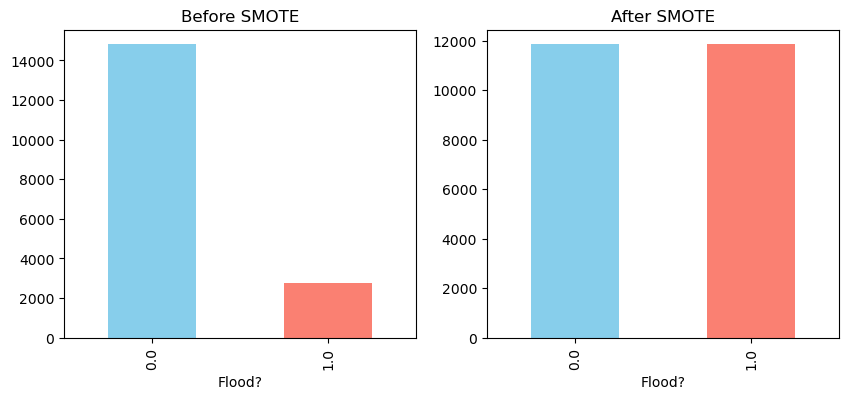

In [17]:
# SMOTE impact showing

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
y.value_counts().plot(kind='bar', ax=ax[0], title='Before SMOTE', color=['skyblue', 'salmon'])
y_train_res.value_counts().plot(kind='bar', ax=ax[1], title='After SMOTE', color=['skyblue', 'salmon'])
plt.show()

✅ Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      2963
         1.0       0.91      0.94      0.92       549

    accuracy                           0.98      3512
   macro avg       0.95      0.96      0.95      3512
weighted avg       0.98      0.98      0.98      3512



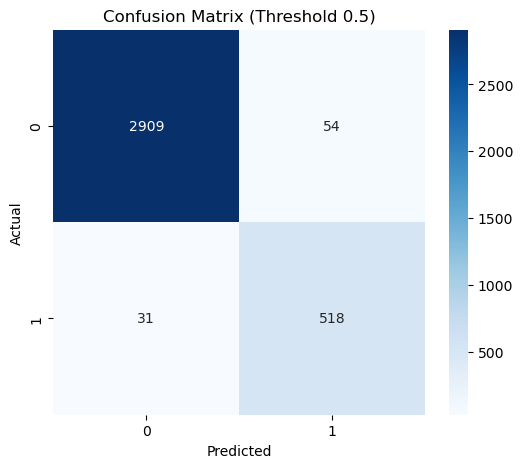

ROC-AUC Score: 0.9946627716333873
RMSE: 0.14075915835423378
Threshold tuning results:
     Threshold  Precision    Recall  F1-score
0        0.10   0.611672  0.992714  0.756944
1        0.15   0.713720  0.985428  0.827850
2        0.20   0.774749  0.983607  0.866774
3        0.25   0.807175  0.983607  0.886700
4        0.30   0.829985  0.978142  0.897993
5        0.35   0.853698  0.967213  0.906917
6        0.40   0.875415  0.959927  0.915725
7        0.45   0.899827  0.948998  0.923759
8        0.50   0.905594  0.943534  0.924175
9        0.55   0.913274  0.939891  0.926391
10       0.60   0.937037  0.921676  0.929293
11       0.65   0.947876  0.894353  0.920337
12       0.70   0.955823  0.867031  0.909265
13       0.75   0.968553  0.841530  0.900585
14       0.80   0.977679  0.797814  0.878636
15       0.85   0.989848  0.710383  0.827147

✅ Classification Report at Threshold 0.5:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      2

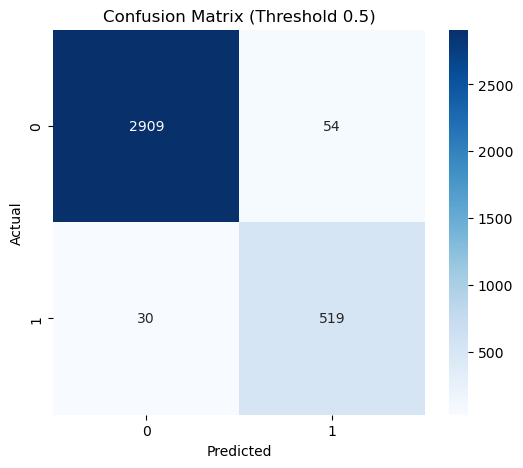

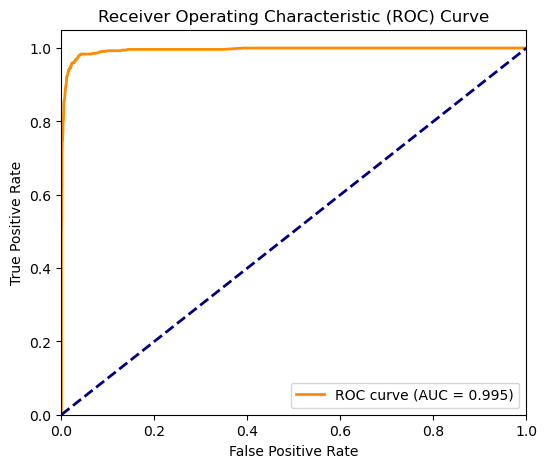

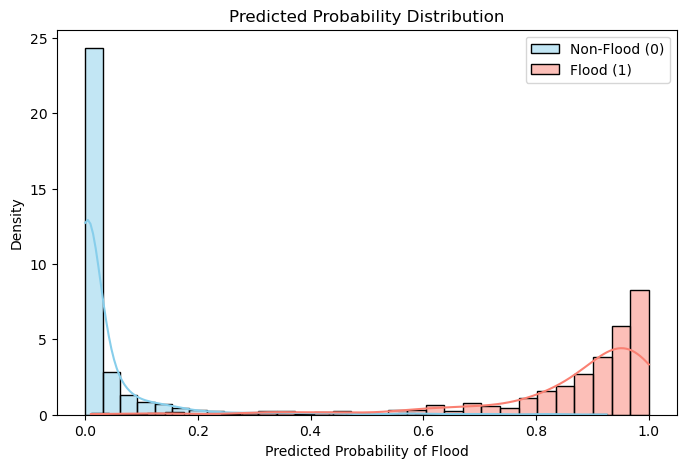

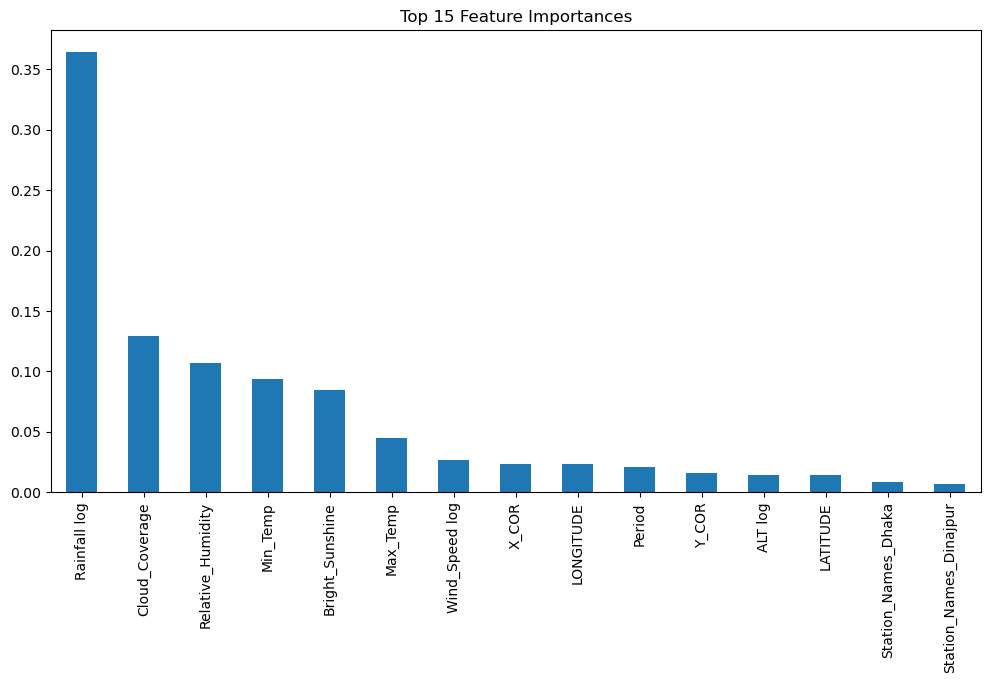

In [ ]:

#  Train Random Forest

#more tree is better accurcy but slower
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_res, y_train_res)


# Predictions and Probabilities

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]


# Evaluate Default Threshold (0.5)

print("✅ Classification Report (Threshold 0.5):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold 0.5)')
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# RMSE
#rmse = np.sqrt(mean_squared_error(y_test, y_proba))
print("RMSE:", rmse)


# Threshold Tuning
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

from sklearn.metrics import precision_recall_fscore_support

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold','Precision','Recall','F1-score'])
print("Threshold tuning results:\n", results_df)

# Choose best threshold (high recall for floods)
best_threshold = 0.50
y_pred_best = (y_proba >= best_threshold).astype(int)

print(f"\n✅ Classification Report at Threshold {best_threshold}:")
print(classification_report(y_test, y_pred_best))

# Confusion matrix for best threshold
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold {best_threshold})')
plt.show()


# ROC Curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# Predicted Probability Distribution
plt.figure(figsize=(8,5))
sns.histplot(y_proba[y_test==0], color='skyblue', label='Non-Flood (0)', bins=30, stat='density', kde=True)
sns.histplot(y_proba[y_test==1], color='salmon', label='Flood (1)', bins=30, stat='density', kde=True)
plt.xlabel('Predicted Probability of Flood')
plt.ylabel('Density')
plt.title('Predicted Probability Distribution')
plt.legend()
plt.show()


# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
importances[:15].plot(kind='bar')
plt.title("Top 15 Feature Importances")
plt.show()


In [39]:
print(X.dtypes)

Max_Temp                                   float64
Min_Temp                                   float64
Rainfall log                               float64
Relative_Humidity                          float64
Wind_Speed log                             float64
Cloud_Coverage                             float64
Bright_Sunshine                            float64
X_COR                                      float64
Y_COR                                      float64
LATITUDE                                   float64
LONGITUDE                                  float64
ALT log                                    float64
Period                                     float64
Station_Names_Bhola                           bool
Station_Names_Bogra                           bool
Station_Names_Chandpur                        bool
Station_Names_Chittagong (City-Ambagan)       bool
Station_Names_Chittagong (IAP-Patenga)        bool
Station_Names_Comilla                         bool
Station_Names_Cox's Bazar      

In [40]:
import joblib

joblib.dump(X.columns.tolist(), 'model_features.pkl')


# Save model
joblib.dump(rf_model, 'flood_model.pkl')

# Save the scaler (important if you used normalization)
joblib.dump(scaler, 'scaler.pkl')

# If you used SMOTE, you don’t need to save it — only used during training


['scaler.pkl']